In [1]:
from itertools import product
import pickle
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from popsummary.popresult import PopulationResult
from astropy.cosmology import Planck15
from astropy import units as u


plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14
plt.rcParams["text.usetex"] = True

In [2]:
def q_flat(x):
    ans=1/(5-(-15))

    return ans


def kl_divergence_kde_p_known_q(p_samples, q_pdf, base=np.e, bandwidth='scott'):
    """
    Estimate KL divergence D_KL(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated KL divergence D_KL(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde = gaussian_kde(p_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde(p_samples)
    q_vals = q_pdf(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_vals = np.clip(q_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_vals)
    kl = np.mean(log_ratio)

    return kl / np.log(base)


def kl_divergence_kde(p_samples, q_samples, base=np.e, bandwidth='scott'):
    """
    Estimate delta divergence D_delta(P || Q) where:
      - P is known via samples (estimated with KDE)
      - Q is known via samples (estimated with KDE)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_samples (array): 1D array of samples from Q
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated delta divergence D_delta(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde_p = gaussian_kde(p_samples, bw_method=bandwidth)

    q_samples = np.asarray(q_samples)
    kde_q = gaussian_kde(q_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde_p(p_samples)
    q_kde_vals = kde_q(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_kde_vals = np.clip(q_kde_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_kde_vals)
    delta = np.mean(log_ratio)

    return delta / np.log(base)

## Use LVK population analysis results as `true' population

In [3]:
gwtc5 = '/home/tristan-bruel/Documents/Science/LVK/gwtc5'
zeval = 0.2
spm_color = '#CD5C5C'

strong_bbh_O4b = PopulationResult(fname=f'{gwtc5}/popsummary_files/gwtc5_updated_default_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_PowerLawRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5')
strong_bbh_O4b_z_grid, strong_bbh_O4b_Rz = strong_bbh_O4b.get_rates_on_grids('redshift')
strong_bbh_O4b_z_grid = strong_bbh_O4b_z_grid.reshape((strong_bbh_O4b_z_grid.size, ))
strong_bbh_O4b_m1_grid, strong_bbh_O4b_Rm1 = strong_bbh_O4b.get_rates_on_grids('mass_1')
strong_bbh_O4b_m1_grid = strong_bbh_O4b_m1_grid.reshape((strong_bbh_O4b_m1_grid.size, ))
strong_bbh_O4b_q_grid, strong_bbh_O4b_Rq = strong_bbh_O4b.get_rates_on_grids('mass_ratio')
strong_bbh_O4b_q_grid = strong_bbh_O4b_q_grid.reshape((strong_bbh_O4b_q_grid.size, ))
redshift_factor_strong_bbh_o4b = (1 + zeval)**(strong_bbh_O4b.get_hyperparameter_samples(hyperparameters=['lamb']))

opening existing popsummary file: /home/tristan-bruel/Documents/Science/LVK/gwtc5/popsummary_files/gwtc5_updated_default_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_PowerLawRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


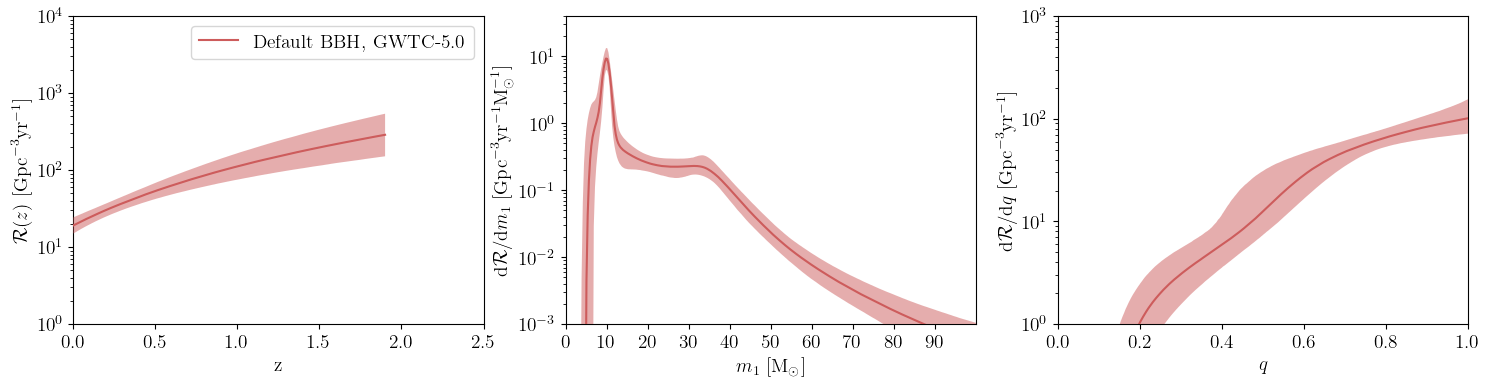

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))

# Merger rate with redshift #
ax = axes[0]
ax.plot(strong_bbh_O4b_z_grid, np.quantile(strong_bbh_O4b_Rz, 0.5, axis = 0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
ax.fill_between(strong_bbh_O4b_z_grid,
        np.quantile(strong_bbh_O4b_Rz, 0.05, axis=0),
        np.quantile(strong_bbh_O4b_Rz, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)

ax.set_xlabel('z')
ax.set_xlim(xmin=0, xmax=2.5)
ax.set_ylabel(r'$\mathcal{R}(z)\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1, ymax=1e4)
ax.legend()

# Primary mass #
ax = axes[1]
ax.plot(strong_bbh_O4b_m1_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.5, axis=0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
ax.fill_between(strong_bbh_O4b_m1_grid,
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.05, axis=0),
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
ax.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
ax.set_xlim(xmin=0, xmax=100)
ax.set_xticks(np.linspace(0,90,10))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_\odot^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1e-3, ymax=4e1)
#ax.legend(loc='upper right', frameon=False)

# Mass ratio #
ax = axes[2]
ax.plot(strong_bbh_O4b_q_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.5, axis=0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
ax.fill_between(strong_bbh_O4b_q_grid,
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.05, axis=0),
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
ax.set_xlabel(r'$q$')
ax.set_xlim(xmin=0, xmax=1)
ax.set_xticks(np.linspace(0,1,6))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1e0, ymax=1e3)
#ax.legend(loc='upper left', frameon=False)


plt.show()
plt.close()

In [5]:
print('R(z=%.2f), integral dR/dm1, integral dR/dq' %zeval)
for ind in range(3):
    Rzeval = interp1d(strong_bbh_O4b_z_grid, strong_bbh_O4b_Rz[ind,:])(zeval)
    int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[ind])
    int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq)[ind])
    print(Rzeval, int_dRdm1, int_dRdq)

R(z=0.20), integral dR/dm1, integral dR/dq
43.85726547616642 43.85646880807036 43.85646880807036
28.035447937840907 28.035349171744507 28.035349171744503
32.88557393041641 32.88561532054052 32.88561532054052


### GW events

In [6]:
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "tilt1", "tilt2"]

data_file = np.load("./lvc_data_lvc_samples_full.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
num_events = data_file["nevents"][0]
num_samples = data_file["nsamples"][0]

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

In [7]:
Tobs = 66997600.0 /(24 * 3600 * 365.25) # in years

### Triangulation setup

In [8]:
z_min = 1e-6
z_max = 2.3
m1_min = 2.0
m1_max = 100.0 + 1e-6
q_min = 1e-6
q_max = 1.

corners_3d = np.array([ 
        [m1_min, z_min, q_min],
        [m1_min, z_min, q_max],
        [m1_min, z_max, q_min],
        [m1_min, z_max, q_max],
        [m1_max, z_min, q_min],
        [m1_max, z_min, q_max],
        [m1_max, z_max, q_min], 
        [m1_max, z_max, q_max],
    ])

print(corners_3d)

[[2.00000000e+00 1.00000000e-06 1.00000000e-06]
 [2.00000000e+00 1.00000000e-06 1.00000000e+00]
 [2.00000000e+00 2.30000000e+00 1.00000000e-06]
 [2.00000000e+00 2.30000000e+00 1.00000000e+00]
 [1.00000001e+02 1.00000000e-06 1.00000000e-06]
 [1.00000001e+02 1.00000000e-06 1.00000000e+00]
 [1.00000001e+02 2.30000000e+00 1.00000000e-06]
 [1.00000001e+02 2.30000000e+00 1.00000000e+00]]


In [9]:
def triangulation_sizes(backend_file, nsteps, nwalkers):
        
    with open(backend_file, "rb") as f:
        back = pickle.load(f)
    return np.array([
        back.inds["tri"][step, 0, walker].sum()
        for step, walker in product(range(nsteps), range(nwalkers))
    ])

In [11]:
nwalkers = 40
nsteps = 1000

In [12]:
backend_file = 'test_lvk_z_m_q/backend'

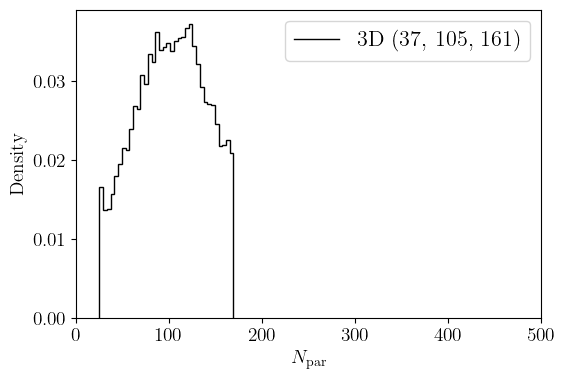

In [13]:
fig, ax = plt.subplots(figsize=(6,4))
ax.set(
    yscale="linear",
    xlabel=r"$N_{\mathrm{par}}$",
    ylabel="Density",
    xlim=(0, 500),
)

ls = ["-", "--", ":"]

ind=0
ndim=3
tri_sizes = triangulation_sizes(backend_file, nsteps, nwalkers)

tri_sizes = np.stack(tri_sizes).ravel() * (ndim + 1) + 2**ndim + 1 

unique, counts = np.unique(tri_sizes, return_counts=True)
fractions = counts / tri_sizes.size

l, m, h = np.quantile(tri_sizes, [0.05, 0.5, 0.95]).astype(int)

edges = np.concatenate(([unique[0]], unique))
ax.stairs(
    fractions,
    edges, 
    color='black', 
    ls=ls[ind], 
    label=f"{ndim}D ({l}, {m}, {h})"
)

ax.legend()
plt.show()
plt.close()

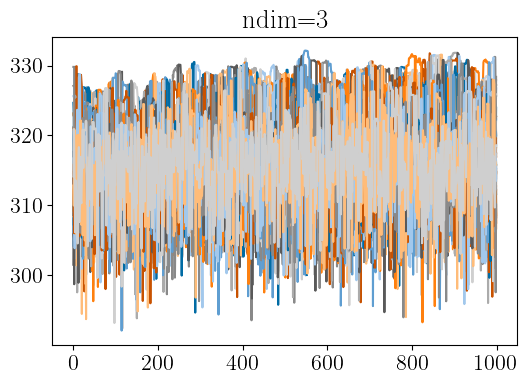

In [14]:
with open(backend_file, "rb") as f:
    back = pickle.load(f)
fig, ax = plt.subplots(figsize=(6,4))
ax.set_rasterized(True)
ax.set(title=f"{ndim=}")
for w in range(nwalkers):
    ax.plot(back.get_log_like()[:, 0, w])
plt.show()
plt.close()

In [15]:
all_triangulations = []

with open(backend_file, "rb") as f:
    back = pickle.load(f)
    triangulations = [
        back.chain["tri"][step, 0, walker][back.inds["tri"][step, 0, walker]]
        for step, walker in product(range(nsteps), range(nwalkers))
    ]

    corner_weights = np.array(
        [
            back.chain["corner_w"][step, 0, walker]
            for step, walker in product(range(nsteps), range(nwalkers))
        ]
    )

for ind in tqdm(range(len(triangulations))):
    all_triangulations.extend([
        np.vstack([triangulations[ind], np.c_[corners_3d, corner_weights[ind].T]])                
    ])

100%|████████████████████████████████| 40000/40000 [00:00<00:00, 106670.94it/s]


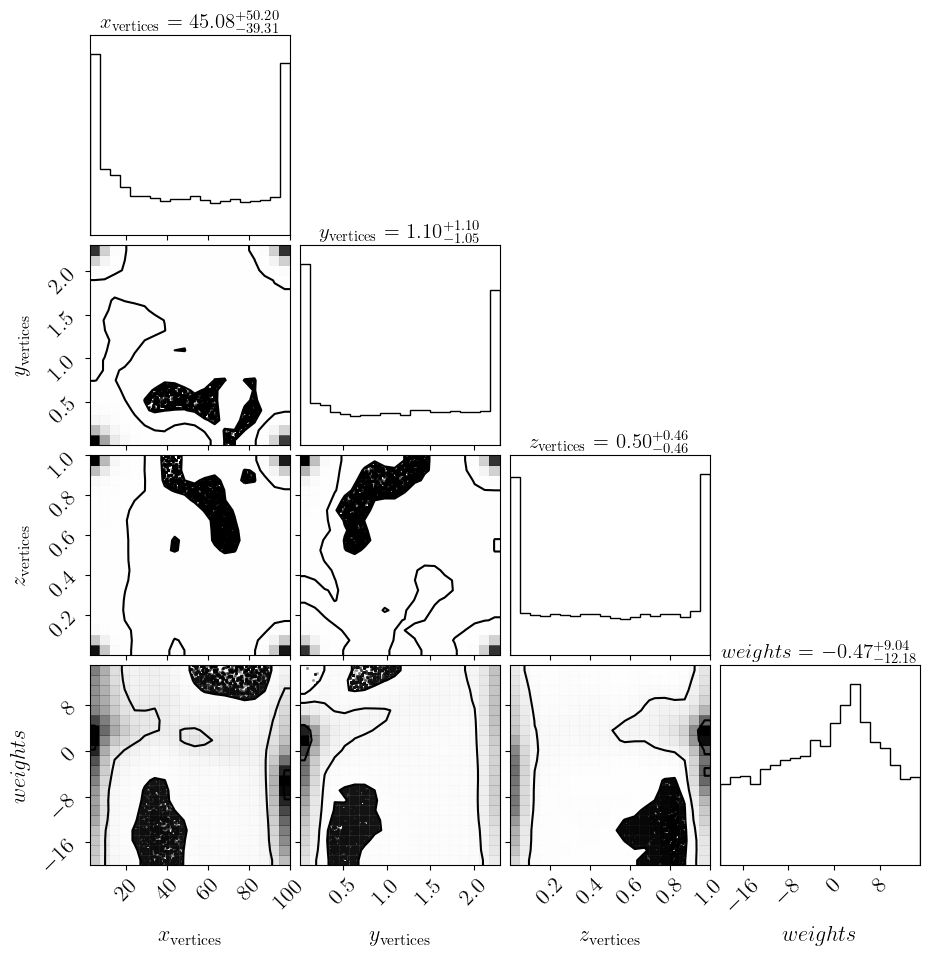

In [16]:
ws = np.hstack([tri[:, -1] for tri in all_triangulations])
vertices = np.vstack([tri[:, :-1] for tri in all_triangulations])    
corner_plot(np.c_[vertices, ws], smooth=True, levels=[0.05, 0.5, 0.95],
            labels=[r"$x_\mathrm{vertices}$", r"$y_\mathrm{vertices}$", r"$z_\mathrm{vertices}$", r"$weights$"],
            show_titles=True,
            title_kwargs={"fontsize": 15},
           )

plt.show()
plt.close()

In [17]:
m1_grid = np.linspace(m1_min, m1_max, 49)
z_grid = np.linspace(0.1, z_max, 50)
q_grid = np.linspace(q_min, q_max, 51)

X, Y, Z = np.meshgrid(m1_grid, z_grid, q_grid)
grid = np.c_[X.ravel(), Y.ravel(), Z.ravel()]

dm1 = m1_grid[1] - m1_grid[0]
dz = z_grid[1] - z_grid[0]
dq = q_grid[1] - q_grid[0]

to_comoving_volume = (1 + z_grid) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value
    )

In [19]:
selected_tris = range(0, len(all_triangulations), 40)
num_triangulations = len(selected_tris)

log_rate = np.zeros((num_triangulations, grid.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate[ind] = this_delo.interpolate(grid)
    
square_rate = log_rate.reshape(num_triangulations, z_grid.shape[0], m1_grid.shape[0], q_grid.shape[0]) \
    #/np.log(10) + np.log10(to_comoving_volume[None,:,None,None])

100%|██████████████████████████████████████| 1000/1000 [00:43<00:00, 23.17it/s]


In [20]:
median = np.quantile(square_rate, 0.5, axis=0)
low = np.quantile(square_rate, 0.05, axis=0)
high = np.quantile(square_rate, 0.95, axis=0)

In [21]:
m1_grid_coarse = np.linspace(m1_min, m1_max, 19)
z_grid_coarse = np.linspace(0.1, z_max, 20)
q_grid_coarse = np.linspace(q_min, q_max, 21)

X_coarse, Y_coarse, Z_coarse = np.meshgrid(m1_grid_coarse, z_grid_coarse, q_grid_coarse)
grid_coarse = np.c_[X_coarse.ravel(), Y_coarse.ravel(), Z_coarse.ravel()]

dm1_coarse = m1_grid_coarse[1] - m1_grid_coarse[0]
dz_coarse = z_grid_coarse[1] - z_grid_coarse[0]
dq_coarse = q_grid_coarse[1] - q_grid_coarse[0]

to_comoving_volume_coarse = (1 + z_grid_coarse) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid_coarse).to(u.Gpc**3 / u.sr).value
    )

In [22]:
log_rate_coarse = np.zeros((num_triangulations, grid_coarse.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_coarse[ind] = this_delo.interpolate(grid_coarse)
    
square_rate_coarse = log_rate_coarse.reshape(num_triangulations, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0]) \
    #/np.log(10) + np.log10(to_comoving_volume_coarse[None,:,None,None])

100%|█████████████████████████████████████| 1000/1000 [00:04<00:00, 214.55it/s]


### Injections

In [23]:
injections_file = np.load("./selection_function_elements.npz")
detected_injections = np.vstack(
    [injections_file[key + "s"] for key in parameter_keys]
).T
injection_priors = injections_file["inj_priors"]
num_injections = injections_file["ninjs"]

## Prior

In [24]:
min_prior = -20
max_prior = 15
nvertices_min = 4
nvertices_max = 40

nsamples_prior = 1_000
log_rate_prior_coarse = np.zeros((nsamples_prior, grid_coarse.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+8,4))
    tri_i[:8,:-1] = corners_3d
    tri_i[8:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[8:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[8:,2] = np.random.uniform(q_min, q_max, nleaves_i)
    tri_i[:,3] = np.random.uniform(min_prior, max_prior, nleaves_i+8)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior_coarse[i] = this_delo.interpolate(grid_coarse)

square_rate_prior_coarse = log_rate_prior_coarse.reshape(nsamples_prior, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0]) \
        #/np.log(10) + np.log10(to_comoving_volume_coarse[None,:,None,None])

100%|█████████████████████████████████████| 1000/1000 [00:04<00:00, 208.11it/s]


In [25]:
Nevents_prior = np.sum(np.exp(square_rate_prior_coarse), axis=(1,2,3)) *dm1_coarse *dz_coarse *dq_coarse
median_prior = np.quantile(Nevents_prior, 0.5)
low_prior = np.quantile(Nevents_prior, 0.05)
high_prior = np.quantile(Nevents_prior, 0.95)

In [26]:
volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))
print('theoretical prior min & max: %.2e, %.2e' %(volume*np.exp(min_prior), volume*np.exp(max_prior)))
print('actual min & max from %i prior realisations: %.2e, %.2e' %(nsamples_prior, Nevents_prior.min(), Nevents_prior.max()))

theoretical prior min & max: 4.65e-07, 7.37e+08
actual min & max from 1000 prior realisations: 7.17e+00, 3.44e+07


## Marginals

(1.0, 1000.0)

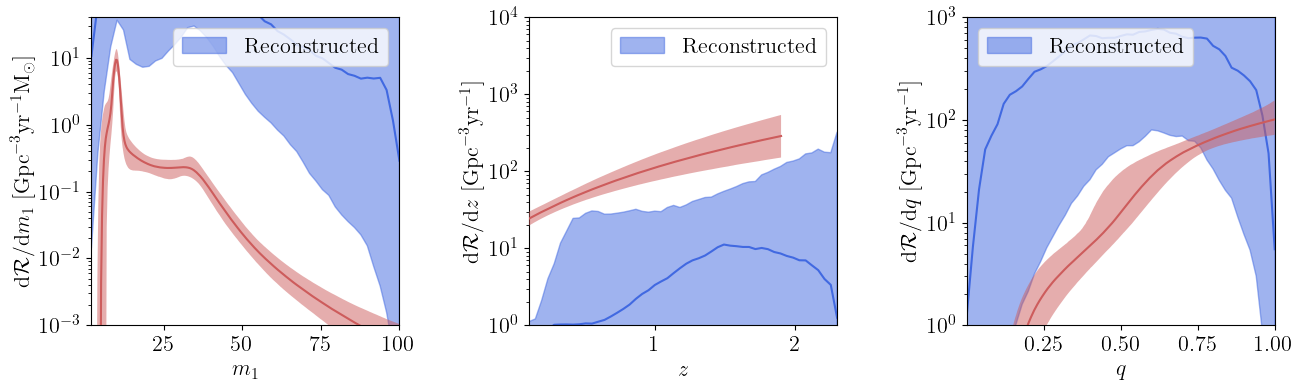

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
x_labels = [r'$m_1$', r'$z$', r'$q$']
grids = [m1_grid, z_grid, q_grid]
grids_coarse = [m1_grid_coarse, z_grid_coarse, q_grid_coarse]
# astro_rates = [x_rate_astro,y_rate_astro,z_rate_astro]
y_labels = [r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}\mathrm{M}_\odot]$',
            r'$\mathrm{d}\mathcal{R}/\mathrm{d}z\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$',
            r'$\mathrm{d}\mathcal{R}/\mathrm{d}q\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$',
            ]
dgrids = np.array([dm1, dz, dq])
# dgrids_coarse = np.array([dm1_coarse, dz_coarse, dq_coarse])
indices = [(1,3),(2,3),(1,2)]
for n,a in enumerate(indices):
    ax = axes[n]
    dRdtheta = np.sum(np.exp(square_rate) *to_comoving_volume[None,:,None,None], axis=a) *dgrids[a[0]-1] *dgrids[a[1]-1]
    # log10_dNd = np.log10(np.sum(np.exp(square_rate_coarse), axis=a) *dgrids_coarse[a[0]-1] *dgrids_coarse[a[1]-1])
    low_dtheta = np.quantile(dRdtheta, 0.05, axis=0)
    median_dtheta = np.quantile(dRdtheta, 0.5, axis=0)
    high_dtheta = np.quantile(dRdtheta, 0.95, axis=0)
    ## Prior ##
    # log10_prior = np.log10(np.sum(np.exp(square_rate_prior_coarse), axis=a) *dgrids_coarse[a[0]-1] *dgrids_coarse[a[1]-1])
    # low_prior = np.quantile(log10_prior, 0.05, axis=0)
    # median_prior = np.quantile(log10_prior, 0.5, axis=0)
    # high_prior = np.quantile(log10_prior, 0.95, axis=0)
    # ax.plot(grids_coarse[n], np.log10(astro_rates[n]),
    #         color="black", ls="--",
    #         label=r"`Astro' pop",
    #         )
    ax.plot(grids[n], median_dtheta, color="royalblue")
    ax.fill_between(grids[n], low_dtheta, high_dtheta,
                    color="royalblue", alpha=0.5,
                    label='Reconstructed',
                    )
    # ax.plot(grids_coarse[n], log10_median, color="royalblue")
    # ax.fill_between(grids_coarse[n], log10_low, log10_high,
    #                 color="royalblue", alpha=0.5,
    #                 label='Reconstructed',
    #                 )
    # ax.plot(grids_coarse[n], median_prior, color="forestgreen", alpha=0.5)
    # ax.fill_between(grids_coarse[n], low_prior, high_prior,
    #                 color="forestgreen", alpha=0.25,
    #                 label='Prior',
    #                 )
    ax.set_xlabel(x_labels[n])
    ax.set_xlim(xmin=grids_coarse[n].min(), xmax=grids_coarse[n].max())
    ax.set_ylabel(y_labels[n])
    ax.set_yscale('log')
    ax.legend(loc='best')
    ax.set_box_aspect(1)



axes[0].plot(strong_bbh_O4b_m1_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.5, axis=0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
axes[0].fill_between(strong_bbh_O4b_m1_grid,
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.05, axis=0),
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
axes[0].set_ylim(ymin=1e-3, ymax=4e1)
axes[1].plot(strong_bbh_O4b_z_grid, np.quantile(strong_bbh_O4b_Rz, 0.5, axis = 0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
axes[1].fill_between(strong_bbh_O4b_z_grid,
        np.quantile(strong_bbh_O4b_Rz, 0.05, axis=0),
        np.quantile(strong_bbh_O4b_Rz, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
axes[1].set_ylim(ymin=1, ymax=1e4)
axes[2].plot(strong_bbh_O4b_q_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.5, axis=0),
        color=spm_color, label='Default BBH, GWTC-5.0', lw=1.5, zorder=5)
axes[2].fill_between(strong_bbh_O4b_q_grid,
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.05, axis=0),
        np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5)
axes[2].set_ylim(ymin=1e0, ymax=1e3)

# 95% - 5% CI 

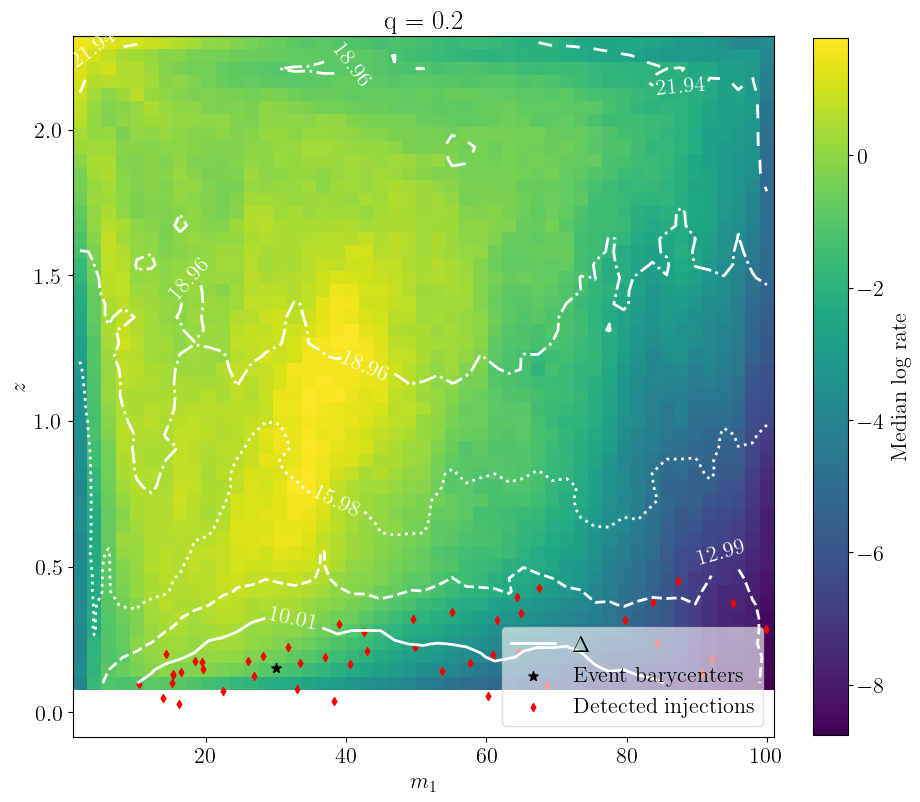

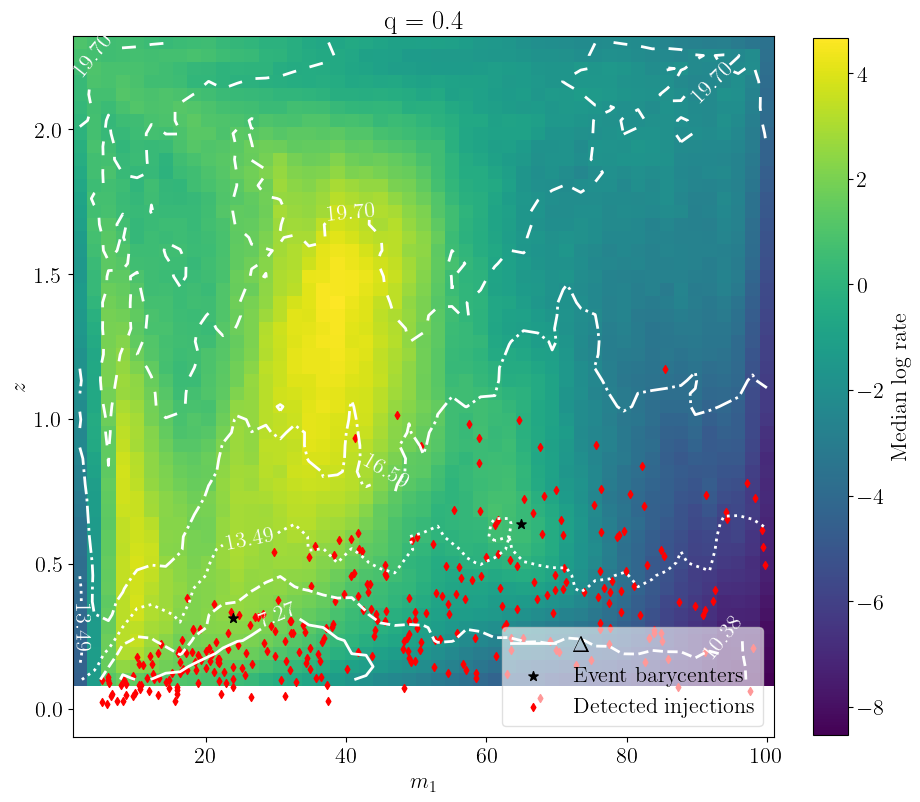

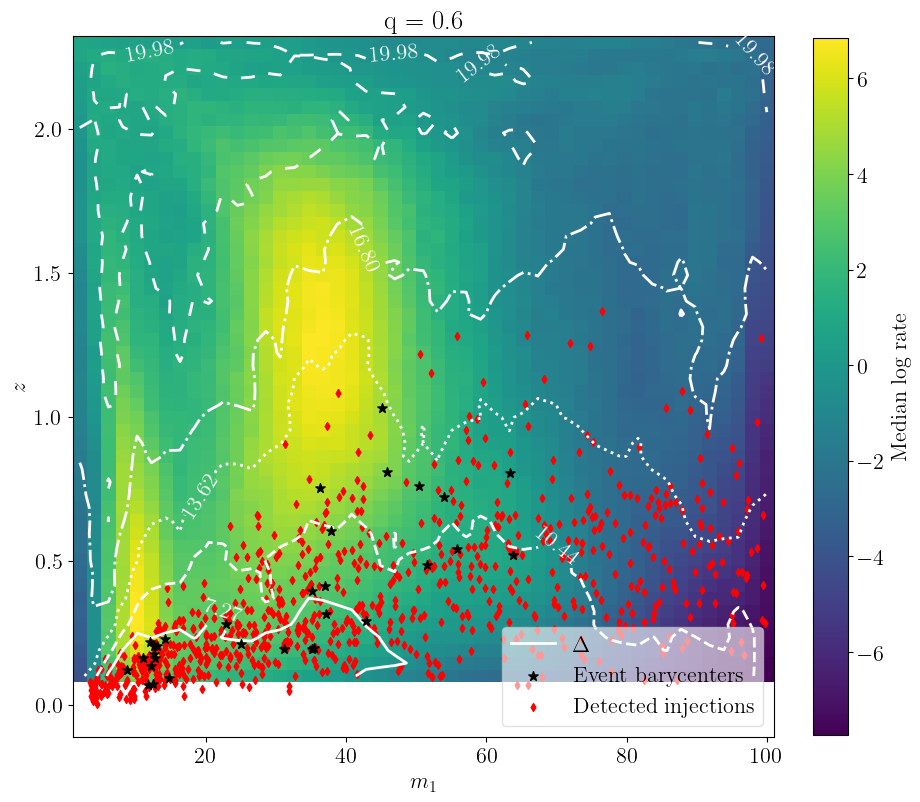

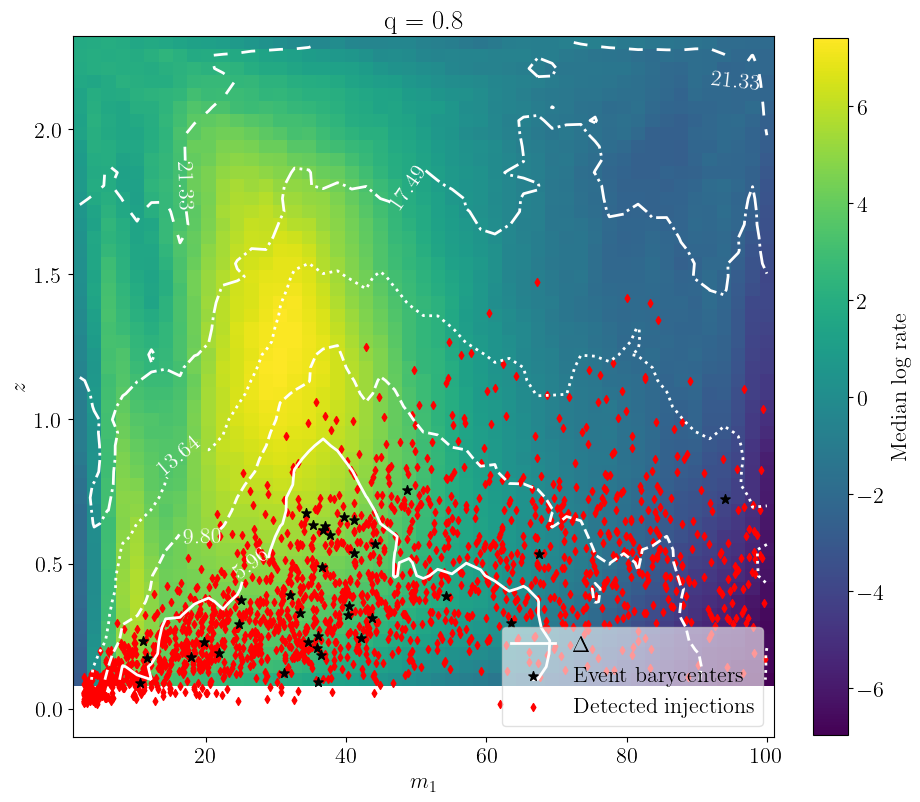

In [28]:
z_indices = [10, 20, 30, 40]

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize


for z_idx in z_indices:
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set(title=f"q = {q_grid[z_idx]:.1f}")
    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, z_idx])    
    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')

    
    # Calculate the difference
    diff = high[:, :, z_idx] - low[:, :, z_idx]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, z_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[z_idx]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_q = np.abs(detected_injections[:,2]-q_grid[z_idx]) < 0.01
    ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='lower right', framealpha=0.6)
    ax.set_box_aspect(1)
    
    plt.show()
    plt.close()

In [ ]:
selected_pop_LVK = range(0, strong_bbh_O4b_Rz.shape[0], 400)
num_pop_LVK = len(selected_pop_LVK)
rate_pop_LVK = np.zeros((num_pop_LVK, len(strong_bbh_O4b_z_grid), len(strong_bbh_O4b_m1_grid)))
for ind,pop_ind in enumerate(tqdm(selected_pop_LVK)):
    int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[pop_ind])
    rate_pop_LVK[ind] = np.outer(strong_bbh_O4b_Rz[pop_ind], (redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[pop_ind] /int_dRdm1)    

In [ ]:
median_LVK = np.quantile(rate_pop_LVK, 0.5, axis=0)

In [ ]:
norm = mpl.colors.Normalize(vmin=-10,vmax=5)

fig, ax = plt.subplots(figsize=(10,10))
c = ax.pcolormesh(strong_bbh_O4b_m1_grid, strong_bbh_O4b_z_grid, np.log(median_LVK),
                 norm=norm,
                 )
cbar = fig.colorbar(c, ax=ax, fraction=0.045)
cbar.set_label(r'Median log rate - LVK')


ax.set_xlabel('$m_1$')
ax.set_xlim(m1_min, m1_max)
ax.set_ylabel('$z$')
ax.set_ylim(z_min, z_max)
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

plt.show()
plt.close()

In [ ]:
interp_delta = RegularGridInterpolator((z_grid, m1_grid, q_grid), high-low, bounds_error=False, fill_value=np.nan)

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = %.1f" %zeval)

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=zeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],c=interp_delta(samples_try[:,(1,0,2)]))

# mu_cond1, Sigma_cond1 = conditional_gaussian(mean1, cov1, 5)
# mu_cond2, Sigma_cond2 = conditional_gaussian(mean2, cov2, 5)

# colors = ['r','g','b']

# for n, c in zip([1,2,3], colors):
#     plot_ellipse(mu_cond1, Sigma_cond1, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=r"%i$\sigma$" %n)
#     plot_ellipse(mu_cond2, Sigma_cond2, ax, n_std=n, edgecolor=c, fill=False, lw=2)
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'$\Delta$')

plt.show()
plt.close()

In [ ]:
delta_levels = np.linspace(np.min(diff), np.max(diff), 20)[1:-1]
print(delta_levels)

In [ ]:
samples_per_tri = 1_000
ndraw = 10_000

ints_delta={}
for delta in delta_levels:

    nprop=0
    nkeep=0
    nkeep_old=0

    print(delta)

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep       
        inds_proposal_keep=np.argwhere(interp_delta(new_points[:,(1,0,2)])<delta)[:,0]
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    selected_tris=np.random.choice(len(all_triangulations), size=num_triangulations, replace=False)

    ints_delta[delta]=np.zeros(num_triangulations)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        ints_delta[delta][ind]= mean_fx * frac_kept * volume

In [ ]:
LVK_quantities = np.zeros((rate_pop_LVK.shape[0],len(delta_levels)))

for delta_ind, delta_level in enumerate(delta_levels):
    print(delta_level)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:

        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_delta(new_points[:,(1,0,2)])<delta_level)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)
    
    frac_kept = nkeep / nprop
    # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)

    for n,pop_ind in enumerate(tqdm(selected_pop_LVK)):
        int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[pop_ind])
        int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq)[pop_ind])
        pdf_m1 = interp1d(x=strong_bbh_O4b_m1_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1)[pop_ind] /int_dRdm1, fill_value="extrapolate")
        rate_z = interp1d(x=strong_bbh_O4b_z_grid, y=strong_bbh_O4b_Rz[0], fill_value="extrapolate")
        pdf_q = interp1d(x=strong_bbh_O4b_q_grid, y=(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq)[pop_ind] /int_dRdq, fill_value="extrapolate")
        def rate_LVK(m,z,q):
            return pdf_m1(m)*rate_z(z)*pdf_q(q)
        #mean_fx = gt_distro.pdf(proposals).mean()
        mean_Nx = (rate_LVK(proposals[:,0],proposals[:,1],proposals[:,2])).mean()
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        
        # LVK_quantities[delta_ind] = true_N * mean_fx * frac_kept * volume
        LVK_quantities[n,delta_ind] = mean_Nx * frac_kept * volume

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = np.quantile(LVK_quantities, 0.5, axis=0)
low_LVK = np.quantile(LVK_quantities, 0.05, axis=0)
high_LVK = np.quantile(LVK_quantities, 0.95, axis=0)
ax.plot(delta_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(delta_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_delta = [ np.median(ints_delta[delta]) for delta  in delta_levels]
low_delta = [ np.quantile(ints_delta[delta], 0.05) for delta  in delta_levels]
high_delta = [ np.quantile(ints_delta[delta], 0.95) for delta  in delta_levels]
ax.plot(delta_levels, median_delta, label='Inferred')
ax.fill_between(delta_levels, low_delta, high_delta, alpha=0.4)

ax.errorbar(delta_levels[-1]*1.05, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='upper left')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()

# KL divergences

In [ ]:
kl_divs=np.zeros((len(y_grid_coarse),len(x_grid_coarse),len(z_grid_coarse)))

for i,j,k in product(range(y_grid_coarse.shape[0]),range(x_grid_coarse.shape[0]),range(z_grid_coarse.shape[0])):
    kl_divs[i,j,k] = kl_divergence_kde(square_rate_coarse[:,i,j,k],square_rate_prior_coarse[:,i,j,k])

In [ ]:
interp_kl = RegularGridInterpolator((y_grid_coarse, x_grid_coarse, z_grid_coarse), kl_divs, bounds_error=False, fill_value=np.nan)

In [ ]:
z_indices = [10, 20, 30, 40]

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize


for z_idx in z_indices:
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set(title=f"z = {z_grid[z_idx]:.1f}")
    c = ax.pcolormesh(x_grid, y_grid, median[:, :, z_idx])    
    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')


    Xz0, Yz0, Zz0 = np.meshgrid(x_grid, y_grid, np.array([z_grid[z_idx]]))
    # grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]
    grid_z0 = np.c_[Yz0.ravel(), Xz0.ravel(), Zz0.ravel()]

    # print(grid_z0.shape)
    # print(interp_kl(grid_z0))
    
    diff = high[:, :, z_idx] - low[:, :, z_idx]
    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_diff = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        x_grid, y_grid, interp_kl(grid_z0).reshape(len(y_grid),len(x_grid)), 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours][::-1],
        linewidths=2, 
        colors='black'
    )
    ax.clabel(contours_kl, fmt="%.2f")
    ax.plot([],[], lw=2, color='k', label='KL')


    # contours_diff = ax.contour(
    #     x_grid, y_grid, diff, 
    #     levels=levels_diff, 
    #     linestyles=linestyles[:n_contours],
    #     linewidths=2, 
    #     colors='white'
    # )
    # ax.clabel(contours_diff, fmt="%.2f")

    mu_cond1, Sigma_cond1 = conditional_gaussian(mean1, cov1, z_grid[z_idx])
    mu_cond2, Sigma_cond2 = conditional_gaussian(mean2, cov2, z_grid[z_idx])

    colors = ['r','g','b']

    for n, c in zip([1,2,3], colors):
        plot_ellipse(mu_cond1, Sigma_cond1, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=r"%i$\sigma$" %n)
        plot_ellipse(mu_cond2, Sigma_cond2, ax, n_std=n, edgecolor=c, fill=False, lw=2)


    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.legend(loc='lower right')
    ax.set_box_aspect(1)
    
    plt.show()
    plt.close()

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"z = 5")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(min_x,max_x,5000)
samples_try[:,1]=np.random.uniform(min_y,max_y,5000)
samples_try[:,2]=5

sc=ax.scatter(samples_try[:,0],samples_try[:,1],c=interp_kl(samples_try[:,(1,0,2)]))

mu_cond1, Sigma_cond1 = conditional_gaussian(mean1, cov1, 5)
mu_cond2, Sigma_cond2 = conditional_gaussian(mean2, cov2, 5)

colors = ['r','g','b']

for n, c in zip([1,2,3], colors):
    plot_ellipse(mu_cond1, Sigma_cond1, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=r"%i$\sigma$" %n)
    plot_ellipse(mu_cond2, Sigma_cond2, ax, n_std=n, edgecolor=c, fill=False, lw=2)
    
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'KL divergence')

plt.show()
plt.close()

In [ ]:
kl_levels = np.linspace(0, np.max(kl_divs), 20)[1:-1]
print(kl_levels)

In [ ]:
samples_per_tri = 1_000
num_triangulations = len(selected_tris)
ndraw = 10_000

ints_kl={}
# volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))
volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))
for kl in np.flip(kl_levels):

    nprop=0
    nkeep=0
    nkeep_old=0

    print(kl)

    proposals=np.zeros((ndraw,3))
    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)

        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points[:,(1,0,2)])>kl)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_kl[kl]=np.zeros(num_triangulations)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        # samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_kl[kl], xmax_kl[kl], ymin_kl[kl], ymax_kl[kl], zmin_kl[kl], zmax_kl[kl], interp, kl, weight_fun=None)
        # # print(len(samples_ind))
        # if len(samples_ind)<samples_per_tri:
        #     inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
        #     samples_ind=samples_ind[inds_to_use]
        
        mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        
        # print(mean_fx,frac_kept,volume)
        ints_kl[kl][ind]= mean_fx * frac_kept * volume
        # ints_kl[kl][ind]= mean_fx * volume

In [ ]:
true_quantities_kl = np.zeros(len(kl_levels))

volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))
for kl_ind, kl_level in enumerate(kl_levels):

    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points[:,(1,0,2)])>kl_level)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop  
        
    # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)
    
    mean_fx = gt_distro.pdf(proposals).mean()
    # frac_kept = len(inds_proposal_keep) / len(proposals)
    
    true_quantities_kl[kl_ind] = true_N * mean_fx * frac_kept * volume

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

median_kl = [ np.median(ints_kl[kl]) for kl  in kl_levels]
low_kl = [ np.quantile(ints_kl[kl], 0.05) for kl  in kl_levels]
high_kl = [ np.quantile(ints_kl[kl], 0.95) for kl  in kl_levels]

ax.plot(kl_levels, true_quantities_kl, "--", color="black", zorder=3, label="True (from `astro' pop)")
ax.plot(kl_levels, median_kl, label='Inferred')
ax.fill_between(kl_levels, low_kl, high_kl, alpha=0.4)

ax.errorbar(0, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

ax.set_xlabel(r'KL')
ax.set_ylabel(r'$\mathcal{N}$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower left')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()

# Else

In [ ]:
# plt.hist(np.log(true_N*gt_distro.pdf(samples_try)))

In [ ]:
# dm_levels=np.linspace(0.5,10,30)

# samples_per_tri = 1_000
# num_triangulations = 500

# volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))

# Sigma_inv = np.linalg.inv(cov1)

# ints_dm={}

# ndraw = 5_000

# proposals=np.zeros((ndraw,3))

# proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
# proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
# proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

# for dm in dm_levels:

#     nprop=0
#     nkeep=0
#     nkeep_old=0

#     print(dm)

#     proposals=np.zeros((ndraw,3))

#     while nkeep<ndraw:
        
#         new_points=np.zeros((ndraw-nkeep,3))
#         new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
#         new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
#         new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)

#         nprop+=ndraw-nkeep

#         diff = new_points - mean1
#         d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)
        
#         inds_proposal_keep=np.argwhere(d2 <= dm**2)[:,0]
#         # frac_kept = len(inds_proposal_keep) / len(proposals)

#         nkeep+=len(inds_proposal_keep)

#         proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

#         nkeep_old+=len(inds_proposal_keep)


#     frac_kept=nkeep/nprop
    
#     # # Compute squared Mahalanobis distances
#     # diff = proposals - mean
#     # d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)

#     # # Fixed threshold
   
#     # mask = d2 <= dm**2    # keep points inside ellipsoid
#     # samples_ind = proposals[mask]

#     # # print(dm)
    
#     # # inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta)[:,0]
#     # frac_kept = np.sum(mask)/ len(proposals)

#     # # print(np.sum(mask))


#     selected_tris=np.random.choice(len(triangulations), size=num_triangulations, replace=False)

#     ints_dm[dm]=np.zeros(num_triangulations)

#     for ind, tri_ind in enumerate(tqdm(selected_tris)):
#         this_delo = delaunaytor.CPUDelaunayInterpolator()
#         this_delo.triangulate(triangulations[tri_ind])
#         # samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_delta[delta], xmax_delta[delta], ymin_delta[delta], ymax_delta[delta], zmin_delta[delta], zmax_delta[delta], interp_delta, delta, weight_fun=None)
#         # # print(len(samples_ind))
#         # if len(samples_ind)<samples_per_tri:
#         #     inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
#         #     samples_ind=samples_ind[inds_to_use]
        
#         mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        
        
#         # print(mean_fx,frac_kept,volume)
#         ints_dm[dm][ind]= mean_fx * frac_kept * volume
#         # ints_kl[kl][ind]= mean_fx * volume
#     # print(np.exp(-6)* frac_kept * volume,np.amax(np.exp(this_delo.interpolate(samples_ind))),np.amax(np.exp(this_delo.interpolate(samples_ind)))*frac_kept * volume)


In [ ]:
# true_quantities_dm = np.zeros(len(dm_levels))

# ndraw = 50_000

# proposals=np.zeros((ndraw,3))

# proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
# proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
# proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

# volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))

# for dm_ind, dm_level in enumerate(dm_levels):

#     # # proposals=np.zeros((ndraw*100,3))

#     # # proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
#     # # proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
#     # # proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

#     # diff = proposals - mean
#     # d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)

#     # # Fixed threshold
   
#     # mask = d2 <= dm_level**2    # keep points inside ellipsoid
#     # samples_ind = proposals[mask]

#     # # print(dm)
    
#     # # inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta)[:,0]
#     # frac_kept = np.sum(mask)/ len(proposals)

#     nprop=0
#     nkeep=0
#     nkeep_old=0

#     # print(dm_level)

#     proposals=np.zeros((ndraw,3))

#     while nkeep<ndraw:
        
#         # print(nkeep)

#         new_points=np.zeros((ndraw-nkeep,3))
#         new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
#         new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
#         new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


#         nprop+=ndraw-nkeep


#         diff = new_points - mean1
#         d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)
        
#         inds_proposal_keep=np.argwhere(d2 <= dm_level**2)[:,0]
#         # frac_kept = len(inds_proposal_keep) / len(proposals)

#         nkeep+=len(inds_proposal_keep)

#         proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

#         nkeep_old+=len(inds_proposal_keep)


#     frac_kept=nkeep/nprop

    

#     #print(np.sum(mask))
        
#     # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)
    
#     mean_fx = gt_distro.pdf(proposals).mean()
#     # frac_kept = np.sum(mask) / len(proposals)
#     true_quantities_dm[dm_ind] = true_N * mean_fx * frac_kept * volume

In [ ]:
# fig, ax = plt.subplots(figsize=(6,6))

# median_dm = [ np.median(ints_dm[dm]) for dm  in dm_levels]
# low_dm = [ np.quantile(ints_dm[dm], 0.05) for dm  in dm_levels]
# high_dm = [ np.quantile(ints_dm[dm], 0.95) for dm  in dm_levels]

# ax.plot(dm_levels, true_quantities_dm, "--", color="black", zorder=3, label="True (from `astro' pop)")
# ax.plot(dm_levels, median_dm, label='Inferred')
# # ax.fill_between(dm_levels, low_dm, high_dm, alpha=0.4)

# ax.errorbar(dm_levels[-1]*1.05, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
#             color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
#             label="Prior",
#            )

# # np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
# ax.set_xlabel(r'$\delta m$')
# ax.set_ylabel(r'$\mathcal{N}$')
# ax.set_yscale('log')

# ax.legend(loc='lower right')
# ax.set_box_aspect(1)
# # plt.savefig("3D_volume_delta")
# plt.show()
# plt.close()

In [ ]:
# ind_marg=1
# ind_keep1=0
# ind_keep2=2

# grids={2:z_grid,1:y_grid,0:x_grid}
# grids_coarse={2:z_grid_coarse,1:y_grid_coarse,0:x_grid_coarse}

# mins={2:min_z,1:min_y,0:min_x}
# maxs={2:max_z,1:max_y,0:max_x}

In [ ]:
# square_rate_2d=np.log10(np.trapezoid(np.exp(square_rate),axis=ind_marg+1,x=grids[ind_marg]))
# square_rate_2d_coarse=np.log10(np.trapezoid(np.exp(square_rate_coarse),axis=ind_marg+1,x=grids_coarse[ind_marg]))

In [ ]:
# median_2d = np.quantile(square_rate_2d, 0.5, axis=0)
# low_2d = np.quantile(square_rate_2d, 0.05, axis=0)
# high_2d = np.quantile(square_rate_2d, 0.95, axis=0)

In [ ]:

# fig, ax = plt.subplots(figsize=(16, 10))
# ax.set(title=f"Median ")
# c = ax.pcolormesh(grids[ind_keep1], grids[ind_keep2], median_2d)    
# fig.colorbar(c)


# # Calculate the difference
# diff = high_2d - low_2d

# # Define contour levels (choose appropriate values for your data)
# n_contours = min(5, len(linestyles))
# levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

# # Plot contours with different linestyles
# contours = ax.contour(
#     grids[ind_keep1], grids[ind_keep2], diff, 
#     levels=levels, 
#     linestyles=linestyles[:n_contours],
#     linewidths=2, 
#     colors='white'
# )


# # mu_cond, Sigma_cond = conditional_gaussian(mean, cov, z_grid[z_idx])

# # colors = ['r','g','b']

# # for n, c in zip([1,2,3], colors):
# #     plot_ellipse(mu_cond, Sigma_cond, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")


# # Optional: add labels to contours
# ax.clabel(contours, fmt="%.2f")

# plt.show()
# plt.close()

In [ ]:
# square_rate_2d_prior_coarse = np.log10(np.trapezoid(np.exp(square_rate_prior_coarse),axis=ind_marg+1,x=grids_coarse[ind_marg]))

# # print(square_rate_prior.shape)

In [ ]:
# kl_divs_2d=np.zeros((len(x_grid_coarse),len(y_grid_coarse)))

# for i in tqdm(range(len(grids_coarse[ind_keep1]))):
#     for j in range(len(grids_coarse[ind_keep2])):
        
#         # print(i,j)

#             # if (i==0 and j==0 and k==0) or (i==0 and j==99 and k==0) or (i==99 and j==0 and k==0) or (i==99 and j==99 and k==0) or (i==0 and j==0 and k==99) or (i==0 and j==99 and k==99) or (i==99 and j==0 and k==99) or (i==99 and j==99 and k==1):
#             # if (i==0 and j==0 and k==0) or (i==0 and j==19 and k==0) or (i==19 and j==0 and k==0) or (i==19 and j==19 and k==0) or (i==0 and j==0 and k==19) or (i==0 and j==19 and k==99) or (i==19 and j==0 and k==19) or (i==19 and j==19 and k==1):

#             #     kl_divs_2d[i,j]=kl_divergence_kde_p_known_q(square_rate_coarse[:,i,j,k],q_flat)

#             # else:

#         kl_divs_2d[i,j]=kl_divergence_kde(square_rate_2d_coarse[:,i,j],square_rate_2d_prior_coarse[:,i,j])

In [ ]:
# interp_2d_kl = RegularGridInterpolator((grids_coarse[ind_keep1], grids_coarse[ind_keep2]), kl_divs_2d, bounds_error=False, fill_value=np.nan)

# X2d,Y2d=np.meshgrid(grids[ind_keep1],grids[ind_keep2])

# grid_2d = np.c_[X2d.ravel(), Y2d.ravel()]


In [ ]:

# fig, ax = plt.subplots(figsize=(16, 10))
# ax.set(title=f"Median ")
# c = ax.pcolormesh(grids[ind_keep1],grids[ind_keep2], median_2d)    
# fig.colorbar(c)


# # Calculate the difference
# diff = high_2d - low_2d

# # Define contour levels (choose appropriate values for your data)
# n_contours = min(5, len(linestyles))
# levels_diff = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

# levels_kl = np.linspace(np.nanmin(kl_divs_2d), np.nanmax(kl_divs_2d), n_contours + 2)[1:-1]  # avoid min/max

# contours_kl = ax.contour(
#     grids[ind_keep1], grids[ind_keep2], interp_2d_kl(grid_2d).reshape((len(x_grid),len(y_grid))), 
#     levels=levels_kl, 
#     linestyles=linestyles[:n_contours],
#     linewidths=2, 
#     colors='white'
# )

# # Plot contours with different linestyles
# contours_diff = ax.contour(
#     grids[ind_keep1], grids[ind_keep2], diff, 
#     levels=levels_diff, 
#     linestyles=linestyles[:n_contours],
#     linewidths=2, 
#     colors='black'
# )


# # mu_cond, Sigma_cond = conditional_gaussian(mean, cov, z_grid[z_idx])

# # colors = ['r','g','b']

# # for n, c in zip([1,2,3], colors):
# #     plot_ellipse(mu_cond, Sigma_cond, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")


# # Optional: add labels to contours
# ax.clabel(contours_diff, fmt="%.2f")

# ax.clabel(contours_kl, fmt="%.2f")

# plt.show()
# plt.close()

In [ ]:
# kl_levels=[0,0.5,1,1.5,2.]
# xmin_2d_kl={}
# xmax_2d_kl={}
# ymin_2d_kl={}
# ymax_2d_kl={}

# for kl in kl_levels:
#     ndraw=10000000
#     proposals=np.zeros((ndraw,2))

#     proposals[:,0]=np.random.uniform(mins[ind_keep1],maxs[ind_keep1],ndraw)
#     proposals[:,1]=np.random.uniform(mins[ind_keep2],maxs[ind_keep2],ndraw)
    


#     inds_proposal_keep=np.argwhere(interp_2d_kl(proposals)>kl-0.02)[:,0]

#     xmin_2d_kl[kl]=np.amin(proposals[inds_proposal_keep,0])
#     xmax_2d_kl[kl]=np.amax(proposals[inds_proposal_keep,0])
#     ymin_2d_kl[kl]=np.amin(proposals[inds_proposal_keep,1])
#     ymax_2d_kl[kl]=np.amax(proposals[inds_proposal_keep,1])



    

In [ ]:

# xmin_kl={}
# xmax_kl={}
# ymin_kl={}
# ymax_kl={}
# zmin_kl={}
# zmax_kl={}
# for kl in kl_levels:
#     ndraw=10000000
#     proposals=np.zeros((ndraw,3))

#     proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
#     proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
#     proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)


#     inds_proposal_keep=np.argwhere(interp_kl(proposals)>kl-0.02)[:,0]

#     xmin_kl[kl]=np.amin(proposals[inds_proposal_keep,0])
#     xmax_kl[kl]=np.amax(proposals[inds_proposal_keep,0])
#     ymin_kl[kl]=np.amin(proposals[inds_proposal_keep,1])
#     ymax_kl[kl]=np.amax(proposals[inds_proposal_keep,1])
#     zmin_kl[kl]=np.amin(proposals[inds_proposal_keep,2])
#     zmax_kl[kl]=np.amax(proposals[inds_proposal_keep,2])


    

In [ ]:
# from scipy.stats import spearmanr
# from ennemi import estimate_corr

# # samples_kl={}
# spearmans_2d_kl={}
# mic_2d_kl={}
# for kl in kl_levels:

#     print(kl)
#     # ndraw=10000000
#     # proposals=np.zeros((ndraw,2))

#     # proposals[:,0]=np.random.uniform(xmin_kl[kl],xmax_kl[kl],ndraw)
#     # proposals[:,1]=np.random.uniform(ymin_kl[kl],ymax_kl[kl],ndraw)


#     # inds_proposal_keep=np.argwhere(interp(proposals)>kl)[:,0]

#     # proposals[inds_proposal_keep]


#     samples_per_tri = 1000
#     num_triangulations=1000
#     selected_tris=np.random.choice(len(triangulations), size=num_triangulations, replace=False)


#     # samples_kl[kl] = np.zeros((num_triangulations, samples_per_tri, 2))

#     spearmans_2d_kl[kl]=np.zeros(num_triangulations)
#     mic_2d_kl[kl]=np.zeros(num_triangulations)

#     for ind, tri_ind in enumerate(tqdm(selected_tris)):
#         this_delo = delaunaytor.CPUDelaunayInterpolator()
#         this_delo.triangulate(triangulations[tri_ind])
#         # samples_ind=this_delo.re_sample(proposals[inds_proposal_keep],nmax=samples_per_tri)
#         # print(len(samples_ind))
#         samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_kl[kl], xmax_kl[kl], ymin_kl[kl], ymax_kl[kl], zmin_kl[kl], zmax_kl[kl], interp_kl, kl, weight_fun=None)
#         if len(samples_ind)<samples_per_tri:
#             print('have to add:',len(samples_ind))
#             inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
#             samples_ind=samples_ind[inds_to_use]
#         # samples_kl[kl][ind] = samples_ind
#         # print(spearmanr(samples_ind),spearmans_kl[kl][ind])
#         spearmans_2d_kl[kl][ind]=spearmanr(samples_ind[:,[ind_keep1,ind_keep2]]).statistic

#         # kde2d=gaussian_kde(samples_ind.T, bw_method='scott')
#         # kdex=gaussian_kde(samples_ind[:,0], bw_method='scott')
#         # kdey=gaussian_kde(samples_ind[:,1], bw_method='scott')

#         # mi_ind=max(0,np.mean(np.log(kde2d(samples_ind.T)/(kdex(samples_ind[:,0])*kdey(samples_ind[:,1])))))

#         # mic_kl[kl][ind]=np.sqrt(1.-np.exp(-2*mi_ind))

#         mic_2d_kl[kl][ind]=estimate_corr(samples_ind[:,ind_keep2],samples_ind[:,ind_keep1])

#         # if np.isnan(mic_kl[kl][ind]):
#         #     print('nan:',mi_ind)


#     #     if ind<10:
            
#     #         plt.figure()
#     #         plt.scatter(samples_ind[:,0],samples_ind[:,1])

#     #         # print(len(samples_ind))

#     # plt.show()
            

In [ ]:

# nsamples_prior=2000
# log_rate_prior = np.zeros((nsamples_prior, grid.shape[0]))

# kl_divs_prior=np.zeros((len(x_grid),len(y_grid)))

# samples_per_tri=1000

# spearmans_prior=np.zeros(nsamples_prior)

# mic_prior=np.zeros(nsamples_prior)


# for i in tqdm(range(nsamples_prior)):

#     nleaves_i=np.random.randint(4,101)

#     tri_i=np.zeros((nleaves_i+8,4))

#     tri_i[:nleaves_i,0]=np.random.uniform(min_x,max_x,nleaves_i)
#     tri_i[:nleaves_i,1]=np.random.uniform(min_y,max_y,nleaves_i)
#     tri_i[:nleaves_i,2]=np.random.uniform(min_z,max_z,nleaves_i)
#     tri_i[:,3]=np.random.uniform(-15,5,nleaves_i+8)

#     tri_i[-8,0]=min_x
#     tri_i[-8,1]=min_y
#     tri_i[-8,2]=min_z

#     tri_i[-7,0]=min_x
#     tri_i[-7,1]=min_y
#     tri_i[-7,2]=max_z


#     tri_i[-6,0]=min_x
#     tri_i[-6,1]=max_y
#     tri_i[-6,2]=min_z


#     tri_i[-5,0]=min_x
#     tri_i[-5,1]=max_y
#     tri_i[-5,2]=max_z


#     tri_i[-4,0]=max_x
#     tri_i[-4,1]=min_y
#     tri_i[-4,2]=min_z

#     tri_i[-3,0]=max_x
#     tri_i[-3,1]=min_y
#     tri_i[-3,2]=max_z

#     tri_i[-2,0]=max_x
#     tri_i[-2,1]=max_y
#     tri_i[-2,2]=min_z

#     tri_i[-1,0]=max_x
#     tri_i[-1,1]=max_y
#     tri_i[-1,2]=max_z

   
#     this_delo = delaunaytor.CPUDelaunayInterpolator()
#     this_delo.triangulate(tri_i)
   
#     samples_ind=this_delo.sample(samples_per_tri)
       
#     spearmans_prior[i]=spearmanr(samples_ind[:,[ind_keep1,ind_keep2]]).statistic


#     # kdexy=gaussian_kde(samples_ind.T, bw_method='scott')
#     # kdex=gaussian_kde(samples_ind[:,0], bw_method='scott')
#     # kdey=gaussian_kde(samples_ind[:,1], bw_method='scott')

#     # mi_ind=np.mean(np.log(kdexy(samples_ind.T)/(kdex(samples_ind[:,0])*kdey(samples_ind[:,1]))))

#     mic_prior[i]=estimate_corr(samples_ind[:,ind_keep2],samples_ind[:,ind_keep1])



In [ ]:
# import seaborn as sns

# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))

# spearmanr_2d_true_obs=spearmanr(np.mean(file_3d['observed_events'].reshape(-1,file_3d['samples_per_event'],3),axis=0)[:,[ind_keep1,ind_keep2]])[0]


# samples_true_pop=gt_distro.rvs(100000)

# spearmanr_2d_true=spearmanr(samples_true_pop[:,[ind_keep1,ind_keep2]])[0]


# # print('spearman obs:',spearmanr_2d_true_obs)

# # file_3d=np.load('data_test_3dim_3D_1000_events_10000_samples_1000000_injections/data.npz')
# # observed_events=file_3d['observed_events']
# # mins, maxs = observed_events.min(axis=0), observed_events.max(axis=0)
# # pad = (maxs - mins) * 0.1
# # bounds = list(zip(mins - pad, maxs + pad))
# # corners_3d = np.array(list(product(*bounds)))

# for kl in kl_levels:

#     sns.histplot( spearmans_2d_kl[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')

# sns.histplot( spearmans_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=spearmanr_2d_true,c='k')
# plt.axvline(x=spearmanr_2d_true_obs,c='k',ls='--')

# ax.legend()


In [ ]:
# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))


# samples_true_pop=gt_distro.rvs(100000)

# mic_2d_true=estimate_corr(samples_true_pop[:,ind_keep2],samples_true_pop[:,ind_keep1])



# mic_2d_true_obs=estimate_corr(np.mean(file_3d['observed_events'].reshape(-1,file_3d['samples_per_event'],3),axis=0)[:,ind_keep2],np.mean(file_3d['observed_events'].reshape(-1,file_3d['samples_per_event'],3),axis=0)[:,ind_keep1])





# for kl in kl_levels:

#     sns.histplot( mic_2d_kl[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')

# sns.histplot( mic_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=mic_2d_true,c='k')
# plt.axvline(x=mic_2d_true_obs,c='k',ls='--')

# ax.legend()